In [1]:
from typing import List, TypedDict
import time

import os
import pathlib

from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
NOTEBOOK_DIR = pathlib.Path().resolve()

CHROMA_PATH = NOTEBOOK_DIR / "chroma_db"

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-miniLM-L6-v2")

if (CHROMA_PATH / "chroma.sqlite3").exists():
    print("Loading existing vector store from disk...")
    vector_store = Chroma(
        collection_name="rag_collection",
        embedding_function=embeddings,
        persist_directory=str(CHROMA_PATH),
    )
else:
    print("Loading PDFs, chunking, and creating vector store...")
    docs = (
        PyPDFLoader(NOTEBOOK_DIR / "documents" / "book1.pdf").load() +
        PyPDFLoader(NOTEBOOK_DIR / "documents" / "book2.pdf").load() +
        PyPDFLoader(NOTEBOOK_DIR / "documents" / "book3.pdf").load()
    )
    chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
    for d in chunks:
        d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

    vector_store = Chroma(
        collection_name="rag_collection",
        embedding_function=embeddings,
        persist_directory=str(CHROMA_PATH),
    )
    for i in range(0, len(chunks), 1000):
        vector_store.add_documents(chunks[i:i+1000])
        print(f"Indexed Batch {i}")
    print(f"Indexed {len(chunks)} chunks.")

Loading existing vector store from disk...


In [3]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [4]:
# 4) LLM + prompt
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [5]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str

In [6]:
def retrieve(state):
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [7]:

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)
def generate(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}


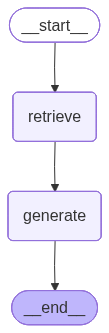

In [8]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)
app = g.compile()

app

In [9]:
# 5) Run
res = app.invoke({"question": "WHat is a transformer in deep learning.", "docs": [], "answer": ""})
print(res["answer"])

which does both the fit() and transform() at once. The 
word "transformer" in scikit-learn has nothing to do 
with the deep learning concept of transformers. 

Unfortunately, I don't have any information about what a transformer is in deep learning.


In [10]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

All transformers also have a convenience method called fit_transform() 
Prepare the Data for Machine Learning Algorithms | 61
 D o w n l o a d   f r o m   f i n e l y b o o k   w w w . f i n e l y b o o k . c o m
****************************************************************************************************
9 “Stacked Convolutional Auto-Encoders for Hierarchical Feature Extraction, ” J. Masci et al. (2011).
10 “GSNs: Generative Stochastic Networks, ” G. Alain et al. (2015).
11 “Winner-Take-All Autoencoders, ” A. Makhzani and B. Frey (2015).
12 “ Adversarial Autoencoders, ” A. Makhzani et al. (2016).
Stacked convolutional autoencoders9
Autoencoders that learn to extract visual fea
tures by reconstructing images pro‐
cessed through convolutional layers.
Generative stochastic network (GSN)10
A generalization of denoising autoencoders, with the added capability to generate
data.
Winner-take-all (WTA) autoencoder11
During training, after computing the activations of all the neurons in 